# Credit Risk Modeling



## IRB Modeling 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

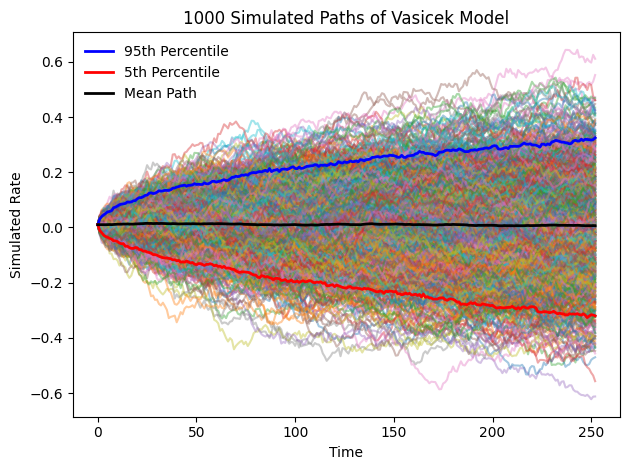

In [2]:
def vasicek_model(r0, kappa, theta, sigma, T, dt, n_paths):
    rng = np.random.default_rng(seed=12)

    n_steps = int(T/dt)
    r = np.zeros((n_steps + 1, n_paths))
    r[0,:] = r0

    for i in range(n_steps):
        dw = rng.normal(size=n_paths)
        dr = kappa * (theta - r[i]) * dt + sigma * np.sqrt(dt) * dw
        r[i+1,:] = r[i,:] + dr

    return r

# Toy examples of the parameter
r0 = 0.01
kappa = 0.02
theta = 0.00
sigma = 0.20
T = 1
dt = 1/252
n_paths = 1000


dr = vasicek_model(r0=r0, kappa=kappa, theta=theta, sigma=sigma, T=T, dt=dt, n_paths=n_paths)

# Plotting the model paths
plt.plot(dr, alpha = 0.40)
plt.plot(np.percentile(dr, 95, axis=1), color = 'b', linewidth = 2, label = '95th Percentile')
plt.plot(np.percentile(dr, 5, axis=1), color = 'r', linewidth = 2, label = '5th Percentile')
plt.plot(dr.mean(axis=1), color = 'black', linewidth = 2, label = 'Mean Path')
plt.legend(loc = 'best', frameon = False)
plt.title(f'{n_paths} Simulated Paths of Vasicek Model')
plt.xlabel('Time')
plt.ylabel('Simulated Rate')
plt.tight_layout()
plt.show()


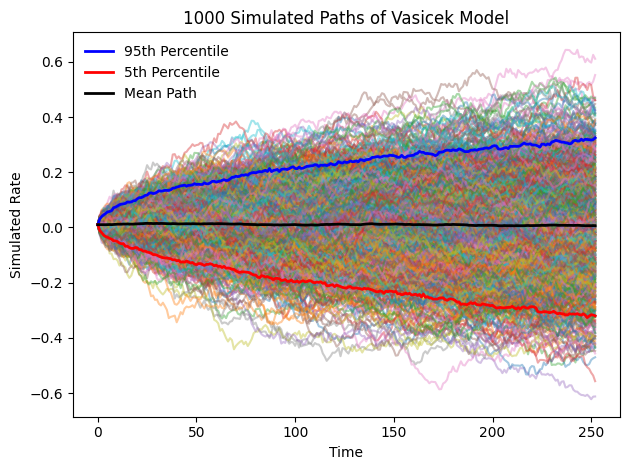

In [7]:
# For cross folder usage of the functions 
import sys
import os
sys.path.append(os.path.abspath('src'))
from vasicek_model import vasicek_model_func

r0 = 0.01
kappa = 0.02
theta = 0.00
sigma = 0.20
T = 1
dt = 1/252
n_paths = 1_000

dr = vasicek_model_func(r0=r0, kappa=kappa, theta=theta, sigma=sigma, T=T, dt=dt, n_paths=n_paths)

# Plotting the model paths
plt.plot(dr, alpha = 0.40)
plt.plot(np.percentile(dr, 95, axis=1), color = 'b', linewidth = 2, label = '95th Percentile')
plt.plot(np.percentile(dr, 5, axis=1), color = 'r', linewidth = 2, label = '5th Percentile')
plt.plot(dr.mean(axis=1), color = 'black', linewidth = 2, label = 'Mean Path')
plt.legend(loc = 'best', frameon = False)
plt.title(f'{n_paths} Simulated Paths of Vasicek Model')
plt.xlabel('Time')
plt.ylabel('Simulated Rate')
plt.tight_layout()
plt.show()

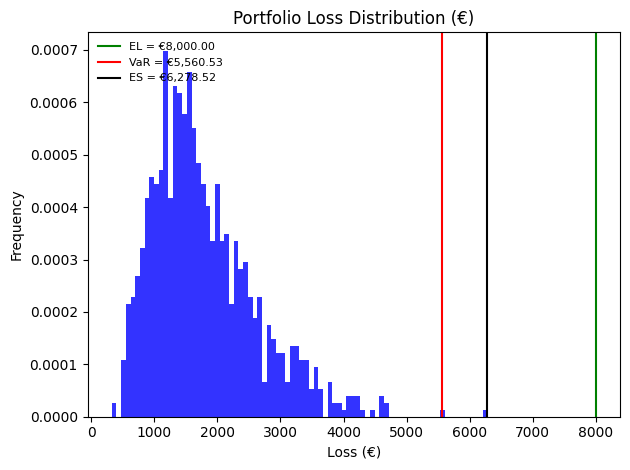

In [79]:
from scipy.stats import norm

# IRB model parameters
def calc_portolio_loss(pd_unconditional, lgd, ead, rho, r_paths):
    default_threshold = norm.ppf(pd_unconditional)
    pd_conditional = norm.cdf((default_threshold + np.sqrt(rho)* r_paths) / np.sqrt( 1 - rho))
    portfolio_loss = pd_conditional * lgd * ead

    return portfolio_loss

pd_unconditional = 0.02
lgd = 0.40
ead = 1_000_000
rho = 0.40
r_paths = dr[-1,:]

all_portfolio_losses = calc_portolio_loss(pd_unconditional=pd_unconditional, lgd=lgd, ead=ead, rho=rho, r_paths=r_paths)
all_portfolio_losses = np.array(all_portfolio_losses)

expected_loss = pd_unconditional * lgd * ead
wcdr = 0.999
VaR = np.percentile(all_portfolio_losses, wcdr * 100)
ES = all_portfolio_losses[all_portfolio_losses >= VaR].mean()
unexpected_loss = VaR - expected_loss

# Plotting the portfolio loss 
plt.hist(all_portfolio_losses, bins=80, color = 'blue', density=True, alpha = 0.80)
plt.axvline(expected_loss, color = 'g', label = f'EL = €{expected_loss:,.2f}')
plt.axvline(VaR, color = 'r', label = f'VaR = €{VaR:,.2f}')
plt.axvline(ES, color = 'black', label = f'ES = €{ES:,.2f}')
plt.legend(loc = 'upper left', frameon = False, fontsize = 8)
plt.title('Portfolio Loss Distribution (€)')
plt.xlabel('Loss (€)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


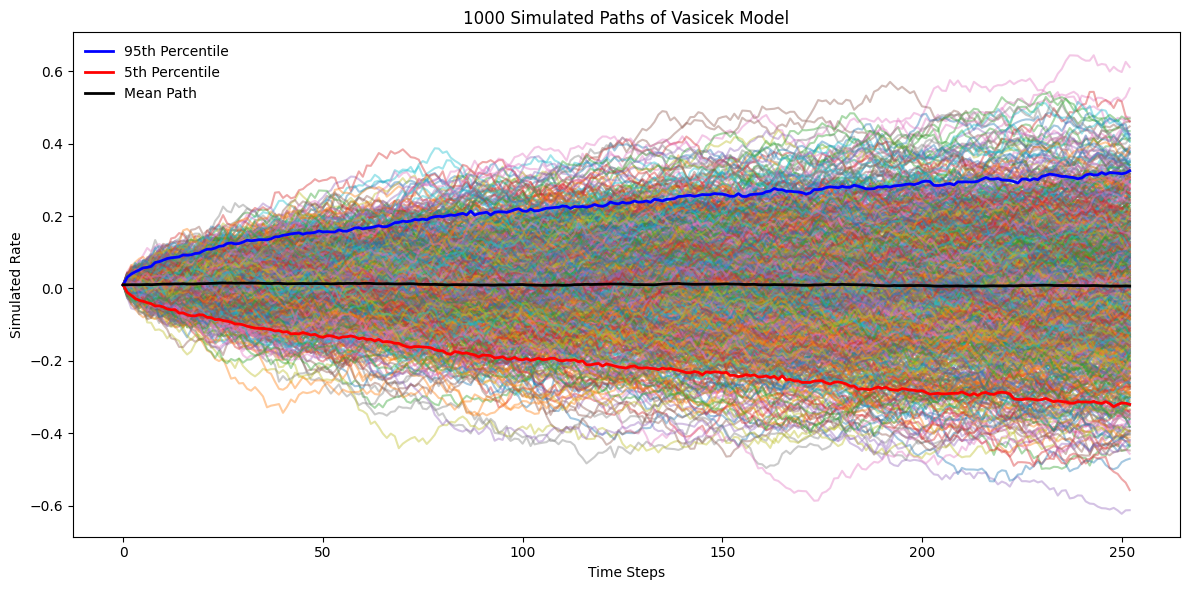

REGULATORY CAPITAL CALCULATION (BASEL IRB APPROACH)
Probability of Default (PD): 2.00%
Loss Given Default (LGD): 45.00%
Exposure at Default (EAD): €1,000,000
Asset Correlation: 0.1641
------------------------------------------------------------
Expected Loss (EL): €9,000
Capital Requirement (99.9%): €76,617
Unexpected Loss (UL): €-9,000
Total Regulatory Capital: €67,617


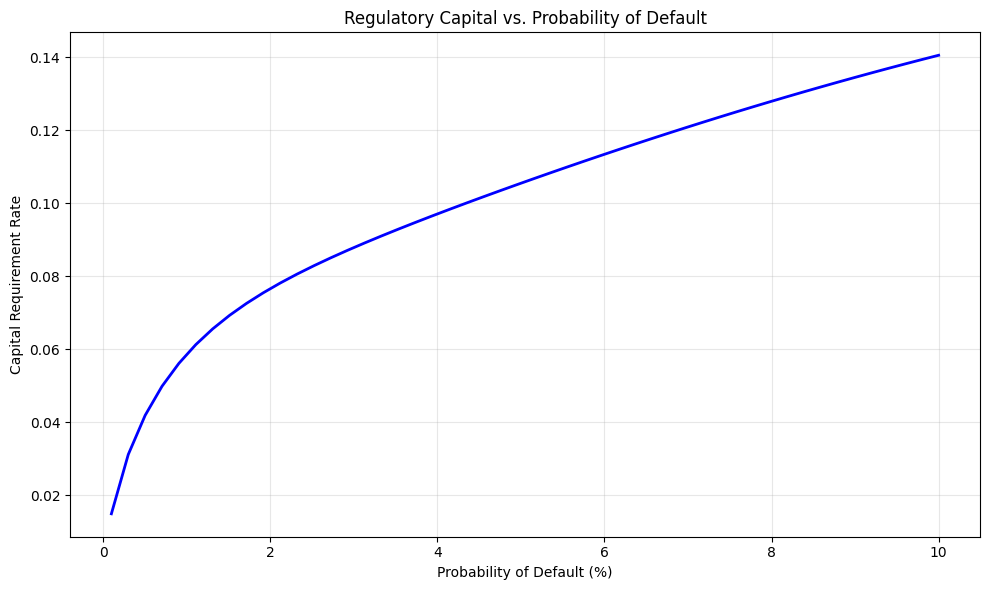

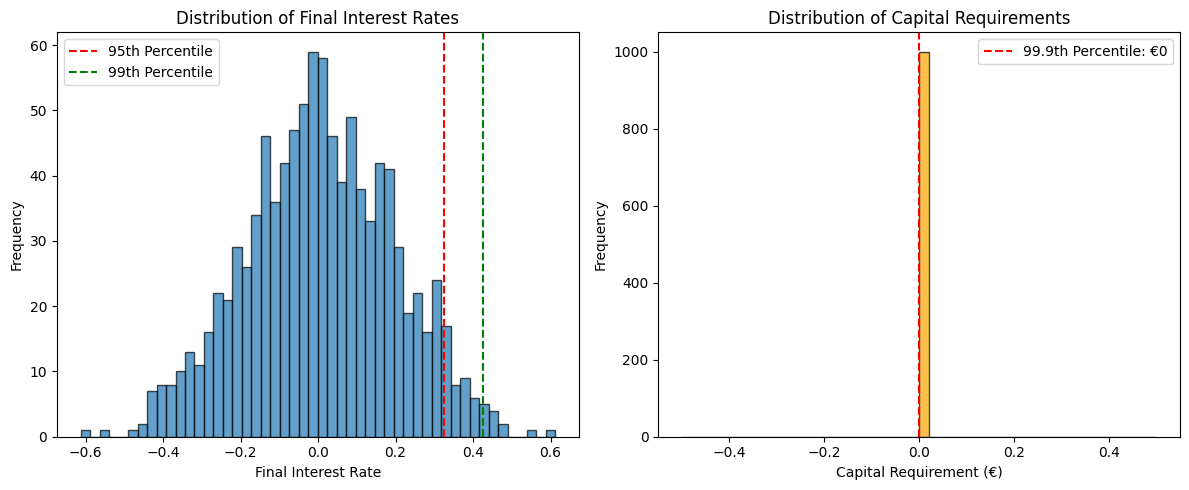

In [8]:
# For cross folder usage of the functions 
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append(os.path.abspath('src'))
from vasicek_model import vasicek_model_func

r0 = 0.01
kappa = 0.02
theta = 0.00
sigma = 0.20
T = 1
dt = 1/252
n_paths = 1_000

# Generate paths (assuming dr.shape = (time_steps, n_paths))
dr = vasicek_model_func(r0=r0, kappa=kappa, theta=theta, sigma=sigma, T=T, dt=dt, n_paths=n_paths)

# Plotting the model paths
plt.figure(figsize=(12, 6))
plt.plot(dr, alpha=0.40)
plt.plot(np.percentile(dr, 95, axis=1), color='b', linewidth=2, label='95th Percentile')
plt.plot(np.percentile(dr, 5, axis=1), color='r', linewidth=2, label='5th Percentile')
plt.plot(dr.mean(axis=1), color='black', linewidth=2, label='Mean Path')
plt.legend(loc='best', frameon=False)
plt.title(f'{n_paths} Simulated Paths of Vasicek Model')
plt.xlabel('Time Steps')
plt.ylabel('Simulated Rate')
plt.tight_layout()
plt.show()

# ============================================
# REGULATORY CAPITAL CALCULATION
# ============================================

def calculate_regulatory_capital(rates_paths, pd, lgd, ead, confidence_level=0.999):
    """
    Calculate regulatory capital using the Vasicek model.
    
    Parameters:
    - rates_paths: Simulated interest rate paths (time_steps, n_simulations)
    - pd: Probability of Default (e.g., 0.02 for 2%)
    - lgd: Loss Given Default (e.g., 0.45 for 45%)
    - ead: Exposure at Default
    - confidence_level: Confidence level for capital calculation (default 99.9%)
    
    Returns:
    - Dictionary with capital metrics
    """
    
    # Use the final rates (maturity T)
    final_rates = rates_paths[-1, :]  # Rates at time T
    
    # Vasicek asymptotic single risk factor (ASRF) model
    # The regulatory capital formula under Basel IRB approach:
    
    # 1. Calculate the asset correlation (R)
    # For corporate exposures: R = 0.12 * (1 - exp(-50*PD)) / (1 - exp(-50)) + 0.24 * (1 - (1 - exp(-50*PD))/(1 - exp(-50)))
    
    def asset_correlation(pd):
        """Calculate asset correlation based on PD"""
        R = 0.12 * (1 - np.exp(-50 * pd)) / (1 - np.exp(-50)) + \
            0.24 * (1 - (1 - np.exp(-50 * pd)) / (1 - np.exp(-50)))
        return R
    
    # 2. Calculate the maturity adjustment (M)
    # M = (1 + (M - 2.5) * b) / (1 - 1.5 * b)
    def maturity_adjustment(pd, maturity=2.5):
        """Calculate maturity adjustment"""
        b = (0.11852 - 0.05478 * np.log(pd)) ** 2
        M_adjustment = (1 + (maturity - 2.5) * b) / (1 - 1.5 * b)
        return M_adjustment
    
    # 3. Calculate capital requirement using Vasicek distribution
    def vasicek_capital(pd, lgd, R, confidence_level=0.999):
        """Vasicek capital formula"""
        # Inverse normal distribution for confidence level
        G_confidence = stats.norm.ppf(confidence_level)
        G_pd = stats.norm.ppf(pd)
        
        # Conditional probability of default
        conditional_pd = stats.norm.cdf((G_pd + np.sqrt(R) * G_confidence) / np.sqrt(1 - R))
        
        # Capital requirement
        capital = lgd * conditional_pd - lgd * pd
        return max(capital, 0)  # Capital cannot be negative
    
    # Parameters for example
    pd = pd if pd else 0.02  # 2% PD
    lgd = lgd if lgd else 0.45  # 45% LGD
    ead = ead if ead else 1_000_000  # €1M exposure
    
    # Calculate correlation
    R = asset_correlation(pd)
    
    # Calculate capital requirement
    capital_rate = vasicek_capital(pd, lgd, R, confidence_level)
    capital_amount = capital_rate * ead
    
    # Calculate Expected Loss (EL)
    expected_loss = pd * lgd * ead
    
    # Calculate Unexpected Loss (UL) as percentile from simulations
    portfolio_losses = lgd * ead * (final_rates > stats.norm.ppf(1-pd))  # Simplified
    unexpected_loss = np.percentile(portfolio_losses, confidence_level * 100) - expected_loss
    
    return {
        'pd': pd,
        'lgd': lgd,
        'ead': ead,
        'asset_correlation': R,
        'capital_requirement_rate': capital_rate,
        'capital_requirement_amount': capital_amount,
        'expected_loss': expected_loss,
        'unexpected_loss': unexpected_loss,
        'total_capital': capital_amount + unexpected_loss
    }

# Example calculation
reg_capital = calculate_regulatory_capital(
    rates_paths=dr, 
    pd=0.02,      # 2% probability of default
    lgd=0.45,     # 45% loss given default
    ead=1_000_000, # €1,000,000 exposure
    confidence_level=0.999  # 99.9% confidence (Basel requirement)
)

# Display results
print("=" * 60)
print("REGULATORY CAPITAL CALCULATION (BASEL IRB APPROACH)")
print("=" * 60)
print(f"Probability of Default (PD): {reg_capital['pd']:.2%}")
print(f"Loss Given Default (LGD): {reg_capital['lgd']:.2%}")
print(f"Exposure at Default (EAD): €{reg_capital['ead']:,.0f}")
print(f"Asset Correlation: {reg_capital['asset_correlation']:.4f}")
print("-" * 60)
print(f"Expected Loss (EL): €{reg_capital['expected_loss']:,.0f}")
print(f"Capital Requirement (99.9%): €{reg_capital['capital_requirement_amount']:,.0f}")
print(f"Unexpected Loss (UL): €{reg_capital['unexpected_loss']:,.0f}")
print(f"Total Regulatory Capital: €{reg_capital['total_capital']:,.0f}")
print("=" * 60)

# Calculate capital for different PD scenarios
pd_range = np.linspace(0.001, 0.10, 50)
capital_range = []

for pd in pd_range:
    R = 0.12 * (1 - np.exp(-50 * pd)) / (1 - np.exp(-50)) + \
        0.24 * (1 - (1 - np.exp(-50 * pd)) / (1 - np.exp(-50)))
    
    G_confidence = stats.norm.ppf(0.999)
    G_pd = stats.norm.ppf(pd)
    conditional_pd = stats.norm.cdf((G_pd + np.sqrt(R) * G_confidence) / np.sqrt(1 - R))
    
    capital_rate = 0.45 * (conditional_pd - pd)
    capital_range.append(capital_rate)

# Plot capital requirement as function of PD
plt.figure(figsize=(10, 6))
plt.plot(pd_range * 100, capital_range, 'b-', linewidth=2)
plt.xlabel('Probability of Default (%)')
plt.ylabel('Capital Requirement Rate')
plt.title('Regulatory Capital vs. Probability of Default')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate capital distribution from simulations
final_rates = dr[-1, :]
capital_distribution = 0.45 * 1_000_000 * (final_rates > stats.norm.ppf(1-0.02))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(final_rates, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(np.percentile(final_rates, 95), color='r', linestyle='--', label='95th Percentile')
plt.axvline(np.percentile(final_rates, 99), color='g', linestyle='--', label='99th Percentile')
plt.xlabel('Final Interest Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Final Interest Rates')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(capital_distribution, bins=50, alpha=0.7, edgecolor='black', color='orange')
plt.axvline(np.percentile(capital_distribution, 99.9), color='r', linestyle='--', 
            label=f'99.9th Percentile: €{np.percentile(capital_distribution, 99.9):,.0f}')
plt.xlabel('Capital Requirement (€)')
plt.ylabel('Frequency')
plt.title('Distribution of Capital Requirements')
plt.legend()

plt.tight_layout()
plt.show()